# Training the LSTMKraus model
---
Loads the training data and trains one `LSTMKraus` model at fixed
$\eta = $ `ETA` (defined in `constants.py`). The model weights are saved
to `data/model<SUFFIX>.pt` where `<SUFFIX>` is `_vary` or `_const`.

In [1]:
import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]
import numpy as np
import torch
import matplotlib.pyplot as plt

from model import LSTMKraus, train
from constants import *
from help_functions import bce_floor, load_history, rho0_torch
import plot_style as ps

SUFFIX = '_vary'   # '_vary' or '_const'
print(f'Training on data/training_data{SUFFIX}_N*.pt -> data/model{SUFFIX}.pt')

Training on data/training_data_vary_N*.pt -> data/model_vary.pt


---
### Load training data
80% of the trajectories are used for gradient updates, 20% for validation.

In [3]:
N_train = 10000   # must match data_generation.ipynb

data = torch.load(f'data/training_data{SUFFIX}_N{N_train}.pt', weights_only=True)

J_train    = data['J_train']
y_train    = data['y_train']
task_train = data['task_train']
J_val      = data['J_val']
y_val      = data['y_val']
task_val   = data['task_val']

print(f'Training trajectories:   {len(J_train)}')
print(f'Validation trajectories: {len(J_val)}')

FileNotFoundError: [Errno 2] No such file or directory: 'data/training_data_vary_N10000.pt'

In [ ]:
bce_floor_train = bce_floor(data['P_train'].numpy(), data['y_train'].numpy())
bce_floor_val   = bce_floor(data['P_val'  ].numpy(), data['y_val'  ].numpy())

print(f'Realised oracle BCE floor (train): {bce_floor_train:.4f}   (N={len(J_train)})')
print(f'Realised oracle BCE floor (val):   {bce_floor_val:.4f}   (N={len(J_val)})')
print(f'Random-guess BCE:                  {np.log(2):.4f}  (ln 2)')

# Patch the saved history file (if it exists) so the plot cell picks up
# the new floor values without re-running training.
import os
hist_path = f'data/history{SUFFIX}.pt'
if os.path.exists(hist_path):
    hist_dict = torch.load(hist_path, weights_only=False)
    hist_dict['bce_floor_train'] = bce_floor_train
    hist_dict['bce_floor_val']   = bce_floor_val
    torch.save(hist_dict, hist_path)
    print(f'Updated {hist_path} with new floors.')

---
### Training
Hyperparameters are the defaults defined in `model.py:train()`. Loss is
binary cross-entropy between the predicted end-measurement probability and
the observed outcome $y \in \{0,1\}$.

In [11]:
model = LSTMKraus()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

history = train(model,
                J_train, J_val,
                y_train, y_val,
                task_train, task_val,
                rho0_torch)

torch.save(model.state_dict(), f'data/model{SUFFIX}.pt')

# Persist curves + BCE floors so the plot cell can overlay both runs.
torch.save({
    'history':         history,
    'bce_floor_train': bce_floor_train,
    'bce_floor_val':   bce_floor_val,
}, f'data/history{SUFFIX}.pt')
print(f'Saved data/model{SUFFIX}.pt and data/history{SUFFIX}.pt')

Parameters: 71,648
Epoch    0 | train 0.6004 | val 0.5407 | lr 9.98e-04 | |g| 23.16
Epoch    1 | train 0.5358 | val 0.5411 | lr 9.86e-04 | |g| 22.94
Epoch    2 | train 0.5315 | val 0.5296 | lr 9.62e-04 | |g| 23.07
Epoch    3 | train 0.5285 | val 0.5353 | lr 9.27e-04 | |g| 19.61
Epoch    4 | train 0.5247 | val 0.5313 | lr 8.81e-04 | |g| 20.41
Epoch    5 | train 0.5269 | val 0.5431 | lr 8.26e-04 | |g| 20.41
Epoch    6 | train 0.5246 | val 0.5346 | lr 7.63e-04 | |g| 18.57
Epoch    7 | train 0.5227 | val 0.5267 | lr 6.94e-04 | |g| 19.55
Epoch    8 | train 0.5232 | val 0.5228 | lr 6.20e-04 | |g| 19.12
Epoch    9 | train 0.5205 | val 0.5262 | lr 5.44e-04 | |g| 17.77
Epoch   10 | train 0.5202 | val 0.5267 | lr 4.66e-04 | |g| 17.01
Epoch   11 | train 0.5184 | val 0.5310 | lr 3.89e-04 | |g| 16.65
Epoch   12 | train 0.5172 | val 0.5240 | lr 3.16e-04 | |g| 16.30
Epoch   13 | train 0.5164 | val 0.5243 | lr 2.47e-04 | |g| 17.49
Epoch   14 | train 0.5149 | val 0.5219 | lr 1.84e-04 | |g| 16.05
Epoch 

---
### Training curves
Loads `data/history_vary.pt` and `data/history_const.pt` if they exist and
overlays both runs in a single figure, so the two training regimes can be
compared after each has been trained.

[vary] Best val BCE:  0.5202 at epoch 17  (gap above floor: +0.0226)
[vary] Final val BCE: 0.5203   (gap above floor: +0.0228, gap from best: +0.0001)
[vary] Final train BCE: 0.5119   (gap above floor: +0.0199)
[const] Best val BCE:  0.4898 at epoch 19  (gap above floor: +0.0046)
[const] Final val BCE: 0.4898   (gap above floor: +0.0046, gap from best: +0.0000)
[const] Final train BCE: 0.4969   (gap above floor: +0.0015)


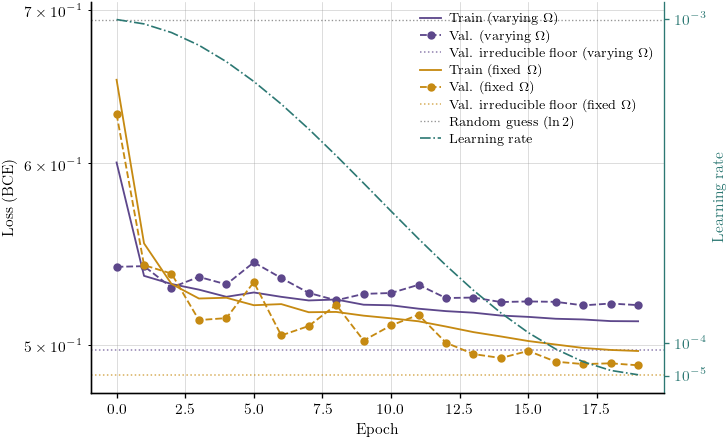

In [12]:
runs = [
    ('vary',  load_history('_vary'),  ps.PALETTE['purple']),
    ('const', load_history('_const'), ps.PALETTE['ochre']),
]

fig, ax = plt.subplots(figsize=ps.figsize(aspect=ps.GOLDEN))
ax_lr = ax.twinx()        # right-hand axis for the learning rate
ax_lr.grid(False)         # keep only the loss-axis grid

# Curves first (vary then const), so the legend groups train/val by model.
for label, hist_dict, color in runs:
    history     = hist_dict['history']
    train_loss  = history['train']
    epochs_axis = np.arange(len(train_loss))
    val_ep, val_loss = zip(*history['val'])
    val_ep   = np.asarray(val_ep,   dtype=int)
    val_loss = np.asarray(val_loss, dtype=float)

    nice_label = 'varying' if label == 'vary' else 'fixed'
    ax.semilogy(epochs_axis, train_loss, color=color, ls='-',
                label=rf'Train ({nice_label} $\Omega$)')
    ax.semilogy(val_ep, val_loss, color=color, ls='--', marker='o',
                label=rf'Val. ({nice_label} $\Omega$)')
    ax.axhline(hist_dict['bce_floor_val'], color=color, ls=':', lw=0.9, alpha=0.7,
               label=rf'Val. irreducible floor ({nice_label} $\Omega$)')

# Shared reference line last, so it sits at the bottom of the legend.
ax.axhline(np.log(2), color=ps.PALETTE['gray'], ls=':', lw=0.8, alpha=0.6,
           label=r'Random guess ($\ln 2$)')

# Learning-rate schedule (shared by both runs) on the right-hand axis.
lr = runs[0][1]['history'].get('lr')
if lr is not None:
    ax_lr.plot(np.arange(len(lr)), lr, color=ps.PALETTE['teal'], ls='-.', lw=1.0,
               label='Learning rate')
    ax_lr.set_ylabel('Learning rate', color=ps.PALETTE['teal'])
    ax_lr.tick_params(axis='y', colors=ps.PALETTE['teal'])
    ax_lr.set_yticks([1e-5, 1e-4, 1e-3])
    ax_lr.set_yticklabels([r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$'])
    ax_lr.spines['right'].set_visible(True)   # global style hides right spines
    ax_lr.spines['right'].set_color(ps.PALETTE['teal'])
else:
    ax_lr.set_yticks([])

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (BCE)')
ax.grid(which='both', alpha=0.5)

# Merge both axes' handles so the learning rate joins the single legend.
h_loss, l_loss = ax.get_legend_handles_labels()
h_lr,   l_lr   = ax_lr.get_legend_handles_labels()
ax.legend(h_loss + h_lr, l_loss + l_lr, loc='upper right',
          fontsize=8, borderaxespad=0.5)

fig.tight_layout()
ps.save_fig(fig, 'training_loss')

for label, hist_dict, _ in runs:
    history    = hist_dict['history']
    floor_val  = hist_dict['bce_floor_val']
    floor_tr   = hist_dict['bce_floor_train']
    val_ep, val_loss = zip(*history['val'])
    val_loss   = np.asarray(val_loss, dtype=float)
    best = int(np.argmin(val_loss))
    print(f'[{label}] Best val BCE:  {val_loss[best]:.4f} at epoch {list(val_ep)[best]}  '
          f'(gap above floor: {val_loss[best] - floor_val:+.4f})')
    print(f'[{label}] Final val BCE: {val_loss[-1]:.4f}   '
          f'(gap above floor: {val_loss[-1] - floor_val:+.4f}, '
          f'gap from best: {val_loss[-1] - val_loss[best]:+.4f})')
    print(f'[{label}] Final train BCE: {history["train"][-1]:.4f}   '
          f'(gap above floor: {history["train"][-1] - floor_tr:+.4f})')